# Time Series Forecasting with ARIMA

<img src="https://i0.wp.com/amanxai.com/wp-content/uploads/2022/06/Time-Series-Forecasting-with-ARIMA-using-Python.png?resize=1200%2C675&ssl=1"/>

In [1]:
import pandas as pd
import yfinance as yf
import datetime
from datetime import date, timedelta

In [3]:
today = date.today()
d1 = today.strftime("%Y-%m-%d")
end_date = d1
d2 = date.today() - timedelta(days=365)
d2 = d2.strftime("%Y-%m-%d")
start_date = d2

data = yf.download('GOOG', 
                      start=start_date, 
                      end=end_date, 
                      progress=False)

In [17]:
data["Date"] = data.index
data = data[["Date", "Open", "High", "Low", "Close", "Volume"]]
data.reset_index(drop=True, inplace=True)
print(data.head())

Price  Date        Open        High         Low       Close    Volume
Ticker             GOOG        GOOG        GOOG        GOOG      GOOG
0         0  149.383565  152.562577  147.031695  147.231018  39832200
1         1  142.895994  154.396229  142.168513  148.725845  47823000
2         2  153.045909  153.907934  144.709737  146.075012  35304400
3         3  145.825878  161.312334  145.307665  160.505127  46479500
4         4  158.213037  159.478666  151.675640  154.834717  35270500


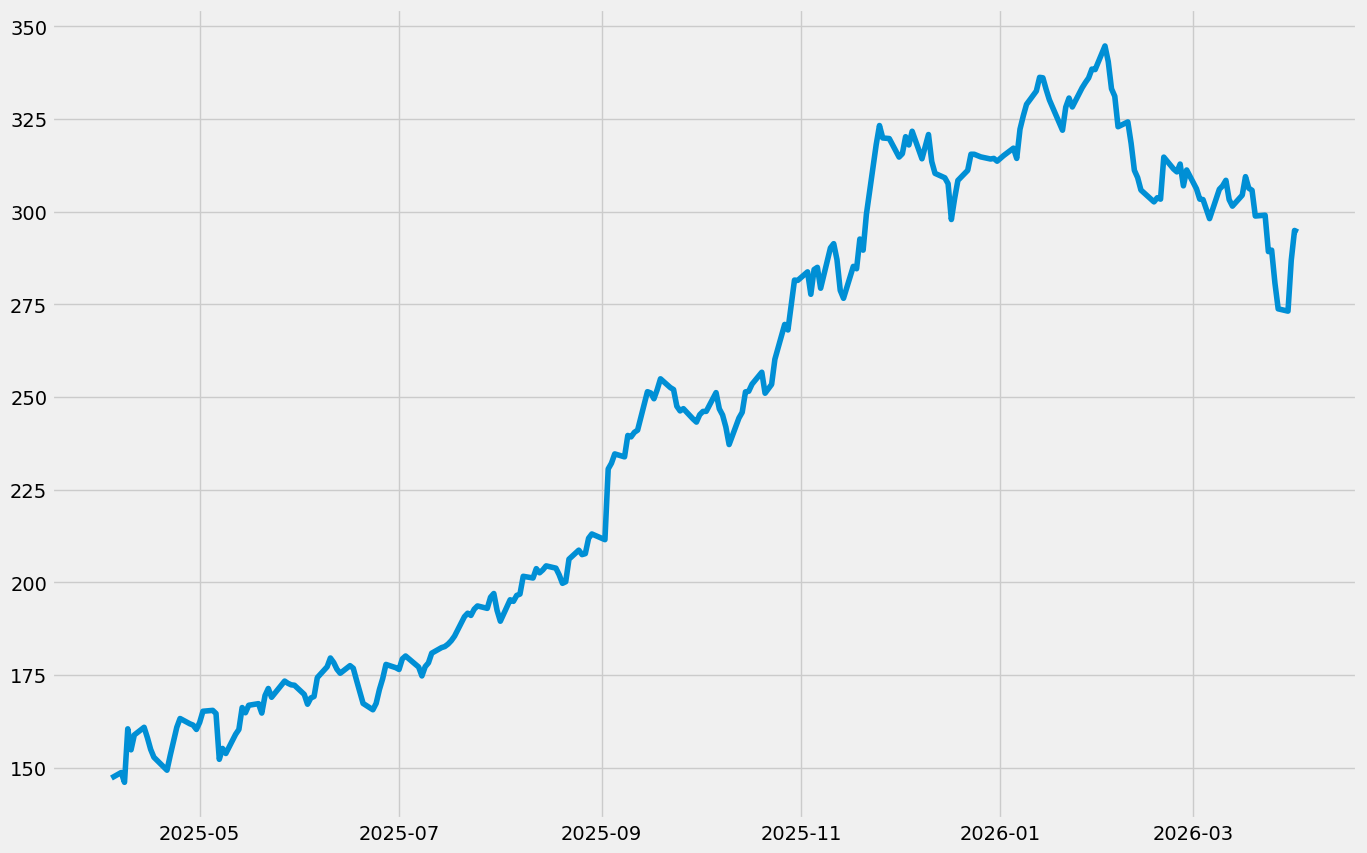

In [6]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15, 10))
plt.plot(data["Date"], data["Close"])

## Using ARIMA for Time Series Forecasting

<Figure size 640x480 with 0 Axes>

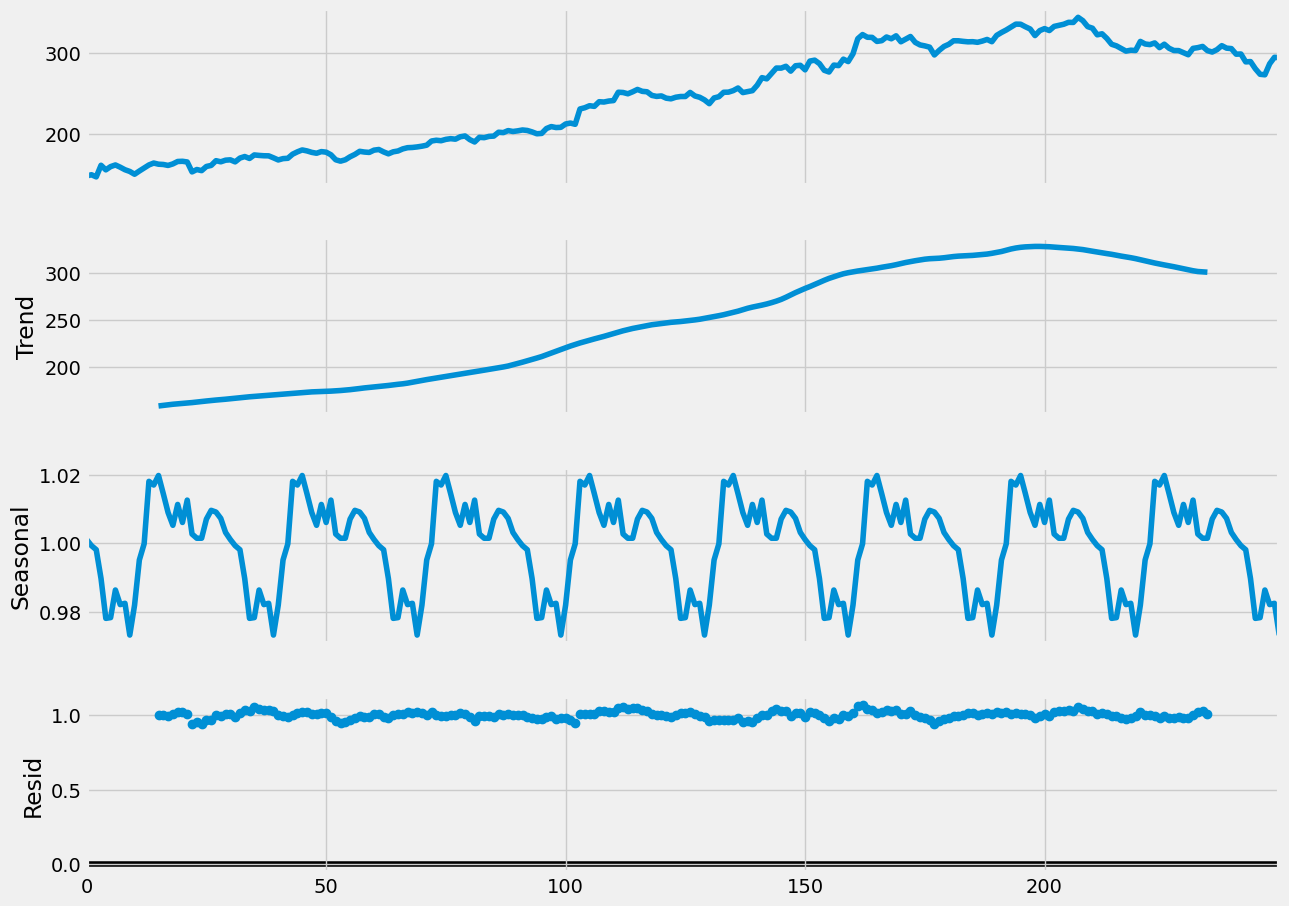

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(data["Close"], 
                            model='multiplicative',period = 30)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(15, 10)

<Axes: xlabel='Lag', ylabel='Autocorrelation'>

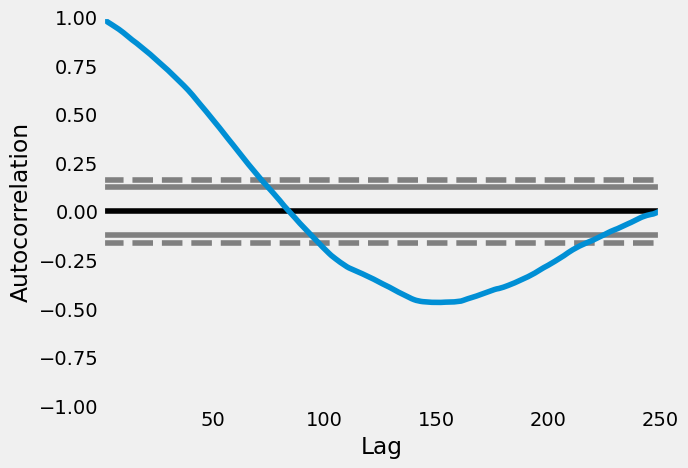

In [9]:
pd.plotting.autocorrelation_plot(data["Close"])

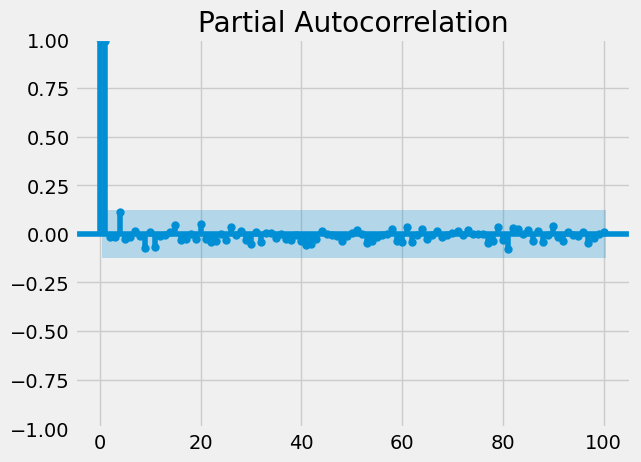

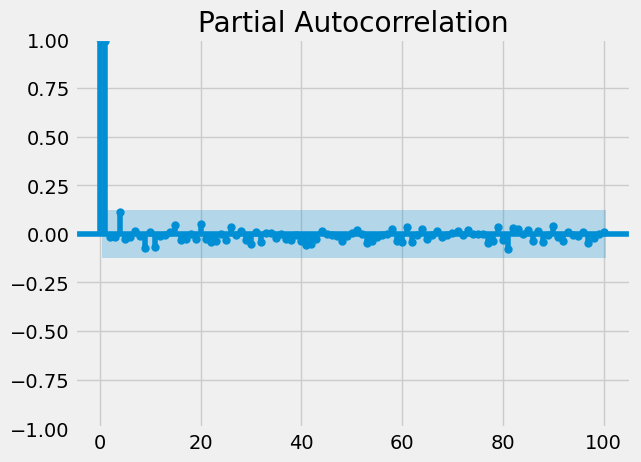

In [10]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(data["Close"], lags = 100)

In [12]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# p, d, q değerleri
p, d, q = 5, 1, 2

# Yeni import yolunu kullanarak modeli kuruyoruz
model = ARIMA(data["Close"], order=(p, d, q))

# Yeni versiyonda 'disp' parametresine gerek yoktur
fitted = model.fit()

# Özeti yazdır
print(fitted.summary())

C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:                   GOOG   No. Observations:                  250
Model:                 ARIMA(5, 1, 2)   Log Likelihood                -723.480
Date:                Sat, 04 Apr 2026   AIC                           1462.960
Time:                        23:49:55   BIC                           1491.099
Sample:                             0   HQIC                          1474.286
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0963      0.569      0.169      0.865      -1.018       1.211
ar.L2          0.9802      0.569      1.721      0.085      -0.136       2.096
ar.L3         -0.0484      0.095     -0.509      0.6

C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
predictions = fitted.predict()
print(predictions)

0        0.000000
1      147.231206
2      148.822102
3      146.015109
4      161.202452
          ...    
245    280.382759
246    272.667541
247    272.760445
248    287.233114
249    296.096416
Name: predicted_mean, Length: 250, dtype: float64


In [14]:
import statsmodels.api as sm
import warnings
model=sm.tsa.statespace.SARIMAX(data['Close'],
                                order=(p, d, q),
                                seasonal_order=(p, d, q, 12))
model=model.fit()
print(model.summary())

C:\Users\tamer\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                               GOOG   No. Observations:                  250
Model:             SARIMAX(5, 1, 2)x(5, 1, 2, 12)   Log Likelihood                -700.087
Date:                            Sat, 04 Apr 2026   AIC                           1430.175
Time:                                    23:55:38   BIC                           1482.196
Sample:                                         0   HQIC                          1451.143
                                            - 250                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4568      1.835      0.249      0.803      -3.139       4.053
ar.L2          0.3753      0.515   

Now let’s predict the future stock prices using the SARIMA model for the next 10 days:

In [15]:
predictions = model.predict(len(data), len(data)+10)
print(predictions)

250    293.732618
251    294.320673
252    294.984271
253    296.253097
254    295.189388
255    296.534876
256    296.562994
257    296.440120
258    297.348456
259    300.333165
260    301.759615
Name: predicted_mean, dtype: float64


<Axes: >

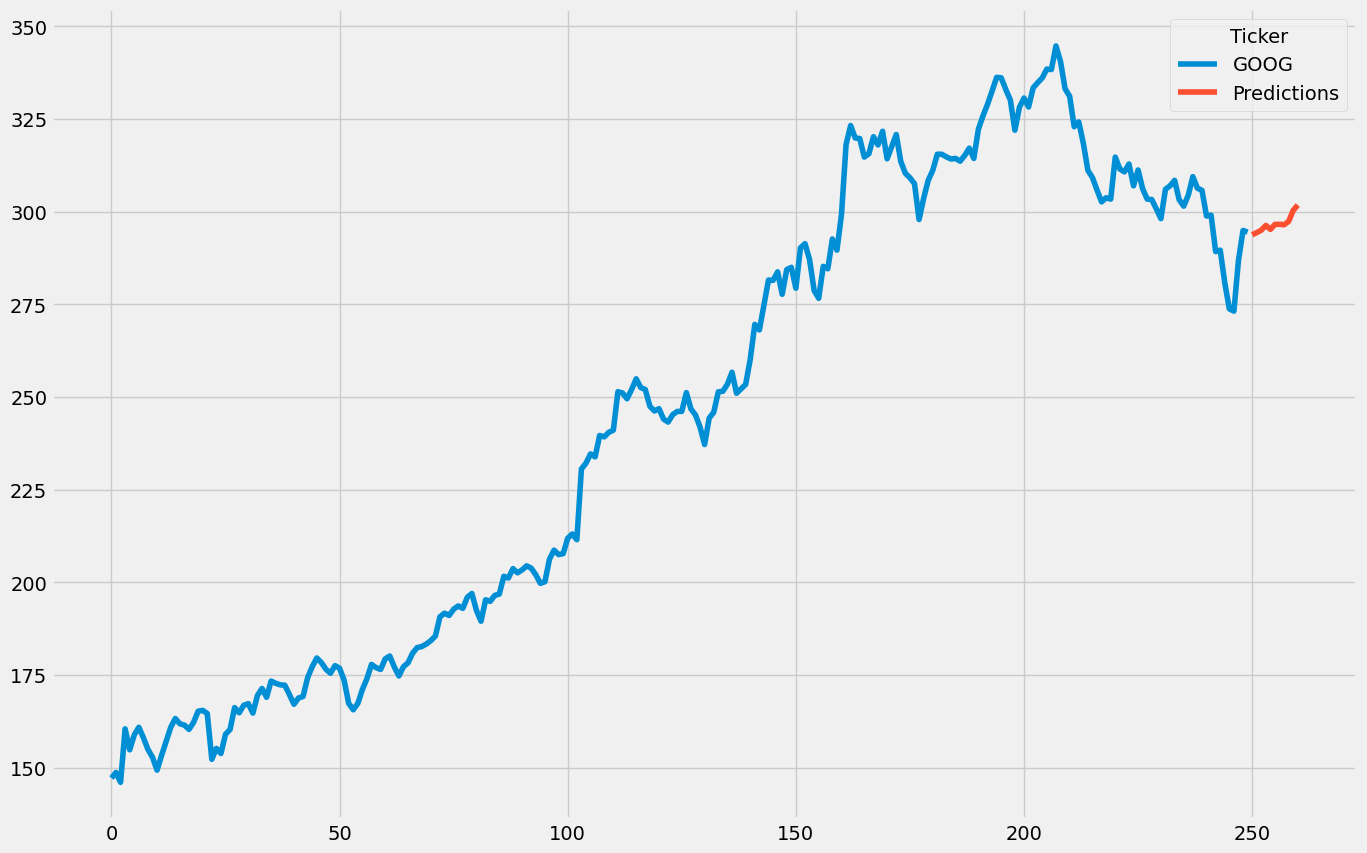

In [16]:
data["Close"].plot(legend=True, label="Training Data", figsize=(15, 10))
predictions.plot(legend=True, label="Predictions")

## Summary
ARIMA stands for Autoregressive Integrated Moving Average. It is an algorithm used for forecasting Time Series Data. If the data is stationary, we need to use ARIMA, if the data is seasonal, we need to use Seasonal ARIMA (SARIMA). I hope you liked this article about Time Series Forecasting with ARIMA using Python. Feel free to ask valuable questions in the comments section below.